In [5]:
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from collections import defaultdict

%matplotlib inline

DATA_ROOT  = Path("../data/raw")
OUTPUT_DIR  = Path("notebooks/eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["Cavity", "Fillings", "Impacted Tooth", "Implant"]
SPLITS      = ["train", "valid", "test"]

CLASS_COLORS = {
    "Cavity":         "#E24B4A",
    "Fillings":       "#378ADD",
    "Impacted Tooth": "#1D9E75",
    "Implant":        "#EF9F27",
}

In [6]:
def load_split(split: str) -> pd.DataFrame:
    records   = []
    label_dir = DATA_ROOT / split / "labels"
    image_dir = DATA_ROOT / split / "images"

    for label_file in sorted(label_dir.glob("*.txt")):
        img_path = None
        for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
            candidate = image_dir / (label_file.stem + ext)
            if candidate.exists():
                img_path = candidate
                break

        img_h, img_w = 640, 640
        if img_path:
            img = cv2.imread(str(img_path))
            if img is not None:
                img_h, img_w = img.shape[:2]

        with open(label_file) as f:
            lines = f.read().strip().split("\n")

        for line in lines:
            if not line.strip():
                continue
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls_id, cx, cy, w, h = int(parts[0]), *map(float, parts[1:])

            records.append({
                "split":      split,
                "filename":   label_file.stem,
                "class_id":   cls_id,
                "class_name": CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f"unknown_{cls_id}",
                "cx":         cx,
                "cy":         cy,
                "w":          w,
                "h":          h,
                "abs_w":      w * img_w,
                "abs_h":      h * img_h,
                "area_norm":  w * h,
                "img_w":      img_w,
                "img_h":      img_h,
            })

    return pd.DataFrame(records)


def load_all_splits() -> pd.DataFrame:
    frames = [load_split(s) for s in SPLITS]
    df = pd.concat(frames, ignore_index=True)
    print(f"[eda] Loaded {len(df)} annotations across {df['filename'].nunique()} images")
    return df


df = load_all_splits()
df.head()

[eda] Loaded 8500 annotations across 1148 images


,split,filename,class_id,class_name,cx,cy,w,h,abs_w,abs_h,area_norm,img_w,img_h
0,train,0001_jpg.rf.ef9e0603ac6eb87150f9ffccacf820d5,1,Fillings,0.548438,0.441406,0.035156,0.140625,22.5,90.0,0.004944,640,640
1,train,0001_jpg.rf.ef9e0603ac6eb87150f9ffccacf820d5,1,Fillings,0.514062,0.445312,0.035156,0.132812,22.5,85.0,0.004669,640,640
2,train,0001_jpg.rf.ef9e0603ac6eb87150f9ffccacf820d5,1,Fillings,0.477344,0.454688,0.032813,0.113281,21.0,72.5,0.003717,640,640
3,train,0001_jpg.rf.ef9e0603ac6eb87150f9ffccacf820d5,1,Fillings,0.442188,0.443750,0.032813,0.152344,21.0,97.5,0.004999,640,640
4,train,0002_jpg.rf.0f6d3f9e2fa3cdbfdc531b071a4c6109,1,Fillings,0.371875,0.324219,0.076563,0.171875,49.0,110.0,0.013159,640,640


In [13]:
def print_summary(df: pd.DataFrame) -> None:
    print("  DATASET SUMMARY")

    for split in SPLITS:
        sub = df[df["split"] == split]
        n_images = sub["filename"].nunique()
        n_annots = len(sub)
        print(f"\n  {split.upper():6s}  {n_images:4d} images  |  {n_annots:5d} annotations")

    print(f"\n  TOTAL   {df['filename'].nunique():4d} images  |  {len(df):5d} annotations")
    print(f"  Avg annotations per image: {len(df)/df['filename'].nunique():.1f}")

    print("\n Class distribution (train split) ")
    train_df = df[df["split"] == "train"]
    for cls in CLASS_NAMES:
        count = len(train_df[train_df["class_name"] == cls])
        pct   = count / len(train_df) * 100
        bar   = "█" * int(pct / 2)
        print(f"  {cls:<16s} {count:5d}  ({pct:5.1f}%)  {bar}")

    print("\n Bounding box size summary ")
    print(f"  Normalised area  min={df['area_norm'].min():.4f}  "
          f"median={df['area_norm'].median():.4f}  "
          f"max={df['area_norm'].max():.4f}")

print_summary(df)

  DATASET SUMMARY

  TRAIN    804 images  |   6008 annotations

  VALID    230 images  |   1708 annotations

  TEST     114 images  |    784 annotations

  TOTAL   1148 images  |   8500 annotations
  Avg annotations per image: 7.4

 Class distribution (train split) 
  Cavity             422  (  7.0%)  ███
  Fillings          3950  ( 65.7%)  ████████████████████████████████
  Impacted Tooth     314  (  5.2%)  ██
  Implant           1322  ( 22.0%)  ███████████

 Bounding box size summary 
  Normalised area  min=0.0000  median=0.0078  max=0.0286


In [ ]:
def flag_data_issues(df: pd.DataFrame) -> None:
    print("\n Data quality flags ")
    issues = []

    tiny = df[df["area_norm"] < 0.0005]
    if len(tiny):
        issues.append(f" {len(tiny)} boxes with area < 0.05% of image (possible noise)")
        print(issues[-1])

    huge = df[df["area_norm"] > 0.64]
    if len(huge):
        issues.append(f" {len(huge)} boxes covering > 80% of image (check labels)")
        print(issues[-1])

    counts = df.groupby("filename").size()
    high   = counts[counts > counts.mean() + 3 * counts.std()]
    if len(high):
        issues.append(f" {len(high)} images with unusually high annotation count:")
        print(issues[-1])
        for fname, cnt in high.items():
            print(f"      {fname}: {cnt} boxes")

    train_counts = df[df["split"] == "train"]["class_name"].value_counts()
    ratio = train_counts.max() / train_counts.min()
    if ratio > 3.0:
        issues.append(f" Class imbalance ratio {ratio:.1f}x "
                      f"({train_counts.idxmax()} vs {train_counts.idxmin()})")
        print(issues[-1])

    image_dir = DATA_ROOT / "train" / "images"
    annotated = set(df[df["split"] == "train"]["filename"].tolist())
    all_imgs  = {p.stem for p in image_dir.glob("*")}
    unannotated = all_imgs - annotated
    if unannotated:
        issues.append(f"  {len(unannotated)} training images have no annotations")
        print(issues[-1])

    if not issues:
        print("  No major data quality issues detected")


flag_data_issues(df)


 Data quality flags 
 6 boxes with area < 0.05% of image (possible noise)
 7 images with unusually high annotation count:
      0546_jpg.rf.1d24c3b34f81049db8632b4c1607bba8: 25 boxes
      0546_jpg.rf.45ec22088ca14939c5a43bab50ff63f3: 25 boxes
      0634_jpg.rf.6d6c10a89c972aa62a6800c65296da95: 23 boxes
      0634_jpg.rf.7c46aa44bcd65eaf9376eba56a3ca977: 23 boxes
      0646_jpg.rf.02b7611b9f3f964a63debe47c8b23603: 26 boxes
      0646_jpg.rf.14f8f8886e7b441b5b034d20efa0c1c1: 26 boxes
      0646_jpg.rf.76a85f280ac45b1c9aae5c36bfc1be89: 26 boxes
 Class imbalance ratio 12.6x (Fillings vs Impacted Tooth)


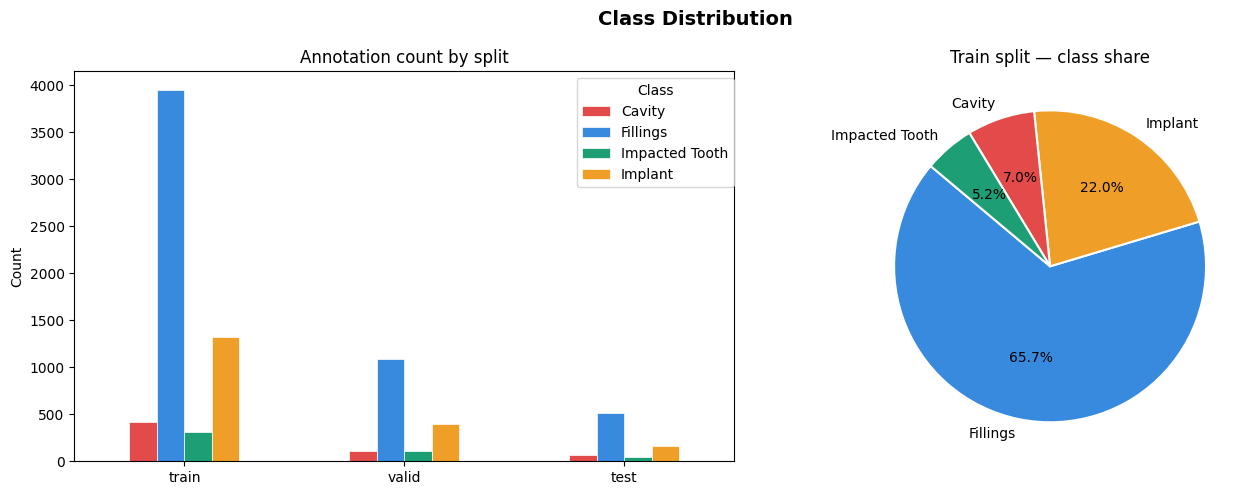

[eda] Saved → notebooks/eda_outputs/01_class_distribution.png


In [9]:
def plot_class_distribution(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Class Distribution", fontsize=14, fontweight="bold")

    pivot = df.groupby(["split", "class_name"]).size().unstack(fill_value=0)
    pivot = pivot.reindex(SPLITS)
    pivot.plot(
        kind="bar", ax=axes[0],
        color=[CLASS_COLORS[c] for c in pivot.columns],
        edgecolor="white", linewidth=0.5
    )
    axes[0].set_title("Annotation count by split")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=0)
    axes[0].legend(title="Class", bbox_to_anchor=(1.01, 1))

    train_counts = df[df["split"] == "train"]["class_name"].value_counts()
    axes[1].pie(
        train_counts,
        labels=train_counts.index,
        colors=[CLASS_COLORS[c] for c in train_counts.index],
        autopct="%1.1f%%",
        startangle=140,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5}
    )
    axes[1].set_title("Train split — class share")

    plt.tight_layout()
    out = OUTPUT_DIR / "01_class_distribution.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[eda] Saved → {out}")

plot_class_distribution(df)

/tmp/ipykernel_148448/48141206.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_148448/48141206.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_148448/48141206.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


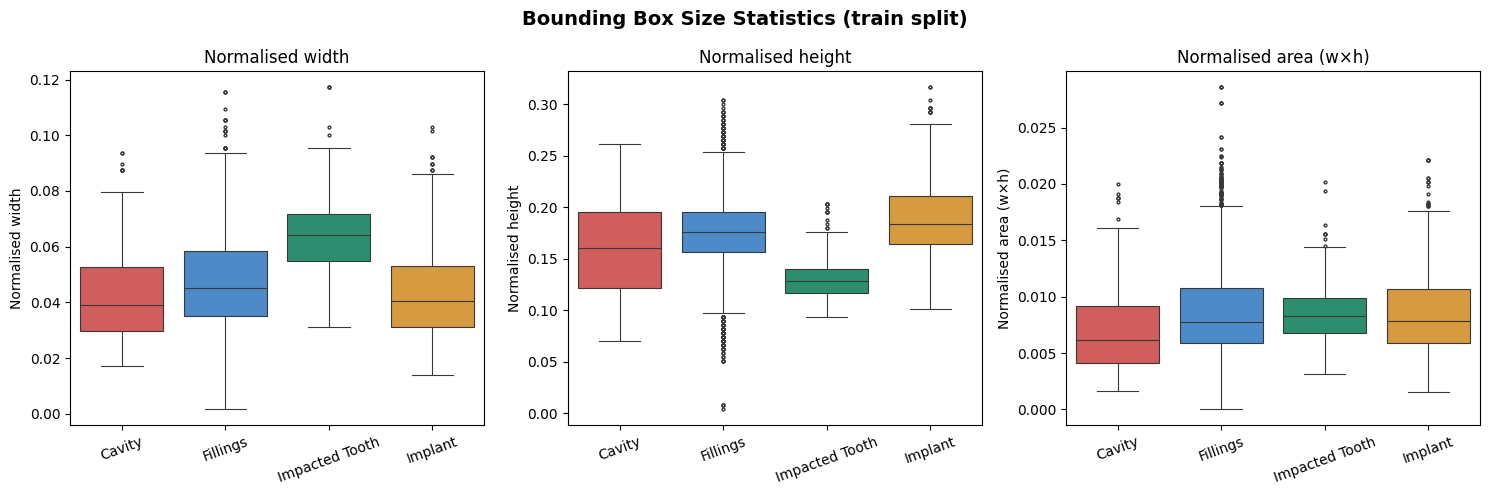

[eda] Saved → notebooks/eda_outputs/02_bbox_statistics.png


In [10]:
def plot_bbox_statistics(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Bounding Box Size Statistics (train split)", fontsize=14, fontweight="bold")

    train_df = df[df["split"] == "train"]
    palette  = [CLASS_COLORS[c] for c in CLASS_NAMES]

    for ax, metric, label in zip(
        axes,
        ["w", "h", "area_norm"],
        ["Normalised width", "Normalised height", "Normalised area (w×h)"]
    ):
        sns.boxplot(
            data=train_df, x="class_name", y=metric,
            palette=palette, ax=ax,
            order=CLASS_NAMES,
            linewidth=0.8, fliersize=2
        )
        ax.set_title(label)
        ax.set_xlabel("")
        ax.set_ylabel(label)
        ax.tick_params(axis="x", rotation=20)

    plt.tight_layout()
    out = OUTPUT_DIR / "02_bbox_statistics.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[eda] Saved → {out}")

plot_bbox_statistics(df)

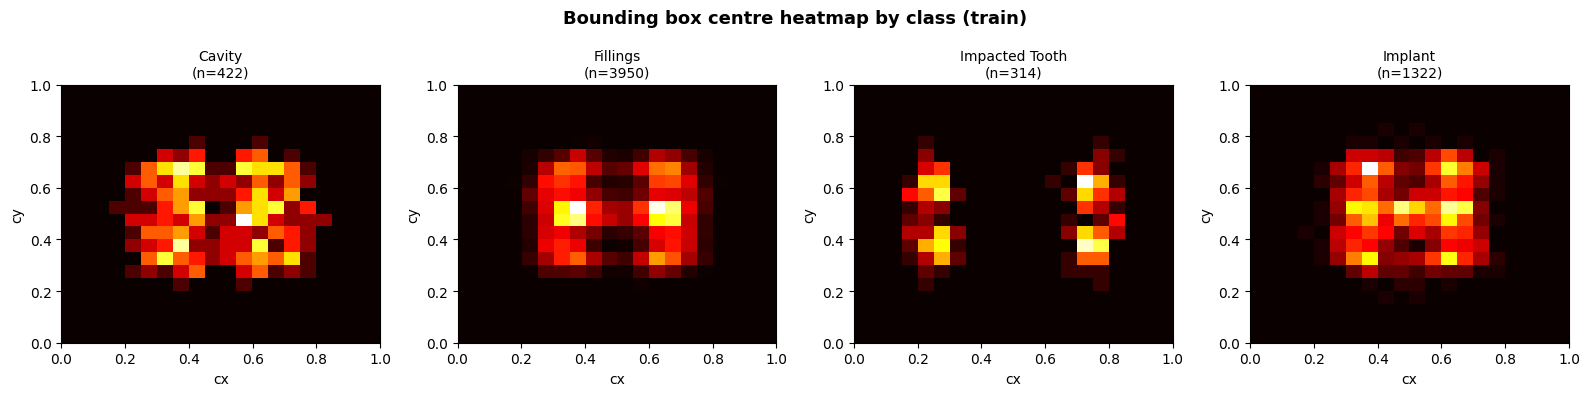

[eda] Saved → notebooks/eda_outputs/03_bbox_heatmap.png


In [11]:
def plot_bbox_heatmap(df: pd.DataFrame) -> None:
    train_df = df[df["split"] == "train"]
    fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(16, 4))
    fig.suptitle("Bounding box centre heatmap by class (train)", fontsize=13, fontweight="bold")

    for ax, cls in zip(axes, CLASS_NAMES):
        sub = train_df[train_df["class_name"] == cls]
        if len(sub) == 0:
            ax.set_title(cls)
            continue

        heatmap, _, _ = np.histogram2d(
            sub["cx"], sub["cy"],
            bins=20, range=[[0, 1], [0, 1]]
        )
        ax.imshow(
            heatmap.T, origin="lower", cmap="hot",
            extent=[0, 1, 0, 1], aspect="auto"
        )
        ax.set_title(f"{cls}\n(n={len(sub)})", fontsize=10)
        ax.set_xlabel("cx")
        ax.set_ylabel("cy")

    plt.tight_layout()
    out = OUTPUT_DIR / "03_bbox_heatmap.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[eda] Saved → {out}")

plot_bbox_heatmap(df)

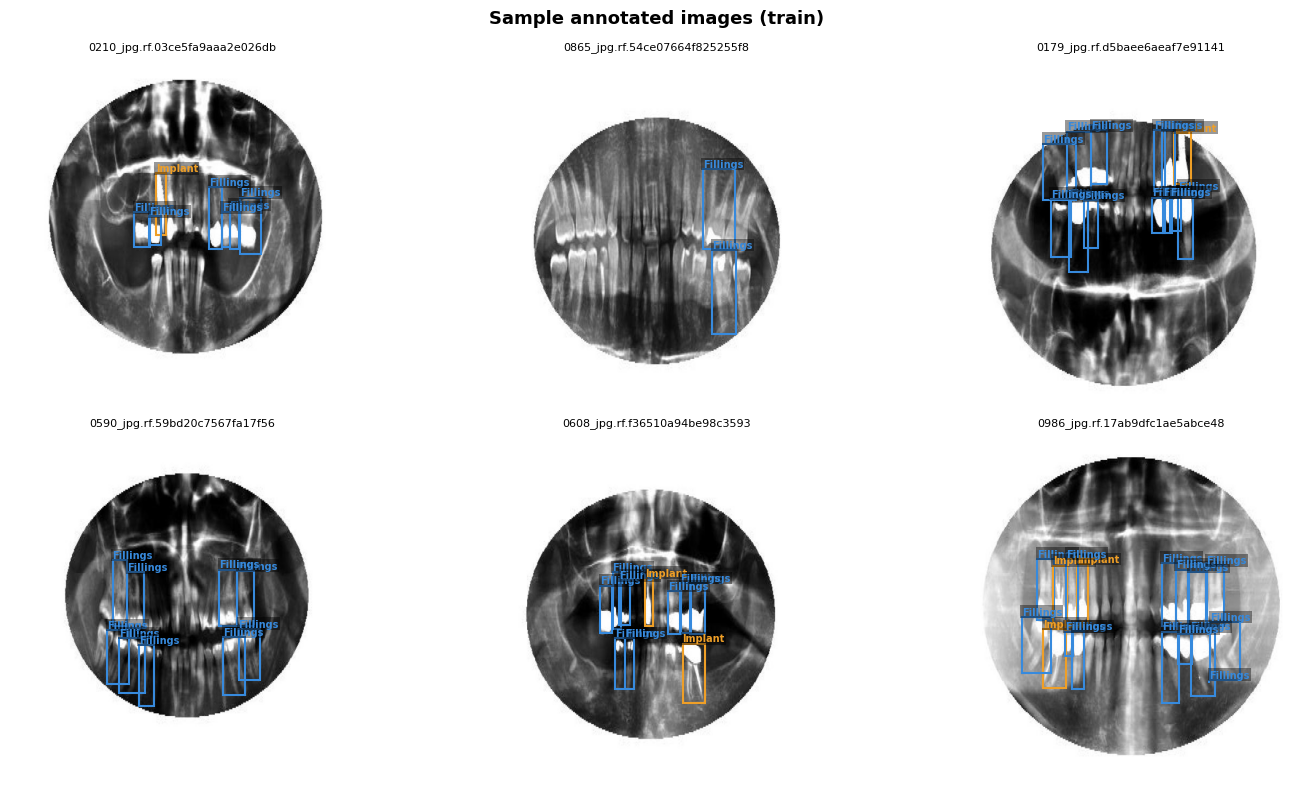

[eda] Saved → notebooks/eda_outputs/04_sample_annotations.png


In [ ]:
def plot_sample_annotations(df: pd.DataFrame, n_samples: int = 6) -> None:
    train_df   = df[df["split"] == "train"]
    image_dir  = DATA_ROOT / "train" / "images"
    sample_imgs = train_df["filename"].drop_duplicates().sample(
        min(n_samples, train_df["filename"].nunique()), random_state=42
    ).tolist()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("Sample annotated images (train)", fontsize=13, fontweight="bold")
    axes = axes.flatten()

    for ax, stem in zip(axes, sample_imgs):
        img_path = None
        for ext in [".jpg", ".jpeg", ".png"]:
            candidate = image_dir / (stem + ext)
            if candidate.exists():
                img_path = candidate
                break

        if img_path is None:
            ax.axis("off")
            continue

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)

        annots = train_df[train_df["filename"] == stem]
        for _, row in annots.iterrows():
            cx, cy, bw, bh = row["cx"], row["cy"], row["w"], row["h"]
            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            color = CLASS_COLORS[row["class_name"]]

            rect = patches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=1.5, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                x1, y1 - 4, row["class_name"],
                fontsize=7, color=color, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.4, pad=1, edgecolor="none")
            )

        ax.set_title(stem[:30], fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    out = OUTPUT_DIR / "04_sample_annotations.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[eda] Saved → {out}")

plot_sample_annotations(df)